# Data Preparation & Pipeline Step-by-Step Validation

2. **Model Loading** (SEN2SRLite using `mlstac`).
3. **Patch Extraction** (Direct windowed range reads).
4. **Super-resolution Inference** (x4 magnification via `sen2sr.predict_large`).
5. **Mask Generation** (LR & SR parcel masks).
6. **Spectral Indices & Export** (Compute statistics, save local GeoTIFFs, and visualize comparison).

In [2]:
import sys
import time
from pathlib import Path
from typing import Union

import geopandas as gpd
import matplotlib.pyplot as plt
import mlstac
import numpy as np
import pandas as pd
import rasterio
import sen2sr
import torch
from rasterio.transform import Affine
from shapely.geometry import box

# Setup src directory path
repo_root = Path.cwd().resolve()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / "src"))

from s2_pipeline import (
    ParcelMaskGenerator,
    ParcelPatchExtractor,
    SpectralIndexComputer,
    TemporalDateMatcher,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
import rasterio

stack_path = r"C:/Users/ahtrabelsi/Desktop/stage/S2 data/Sentinel2_T31UEQ_TSG.tif"

parcels_path = repo_root / "data" / "2020_buf20" / "2020_buf20.shp"
calendar_path = repo_root / "data" / "Sentinel2_T31UEQ_interpolation_dates.txt"
out_dir = repo_root / "yellowness_dataset"
out_dir.mkdir(parents=True, exist_ok=True)

In [4]:
# --- Load Model ---
def load_sr_model(model_url: str, model_dir: Path, device: torch.device):
    print(f"[MODEL] Loading SEN2SRLite from {model_dir} on {device}...")
    load_start = time.perf_counter()
    mlstac.download(file=model_url, output_dir=str(model_dir))
    model = mlstac.load(str(model_dir)).compiled_model(device=str(device))
    model.eval()
    print(f"[MODEL] SEN2SRLite ready in {time.perf_counter() - load_start:.2f}s")
    return model

MODEL_URL = "https://huggingface.co/tacofoundation/sen2sr/resolve/main/SEN2SRLite/main/mlm.json"
MODEL_DIR = repo_root / "model" / "SEN2SRLite"

SEN2SRLite = load_sr_model(MODEL_URL, MODEL_DIR, device)

[MODEL] Loading SEN2SRLite from C:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution\model\SEN2SRLite on cpu...


[MODEL] SEN2SRLite ready in 13.41s


In [5]:
# --- Load Inputs (Remote metadata queries) ---
matcher = TemporalDateMatcher(calendar_path)
gdf = gpd.read_file(parcels_path)
print(f"Loaded shapefile with {len(gdf)} parcels.")


with rasterio.open(stack_path) as src:
    parcels = gdf.to_crs(src.crs)
    # filter parcels to those intersecting raster bounding box
    parcels = parcels[parcels.intersects(box(*src.bounds))].reset_index(drop=True)
    crs = src.crs
    raster_transform = src.transform
    img_height = src.height
    img_width = src.width
    print(f"Filtered down to {len(parcels)} parcels intersecting Sentinel-2 tile.")

Loaded shapefile with 324 parcels.
Filtered down to 62 parcels intersecting Sentinel-2 tile.


In [6]:
# --- Define helper functions ---
def write_geotiff(
    path: Path,
    array: np.ndarray,
    height: int,
    width: int,
    count: int,
    transform: Affine,
) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    profile = {
        "driver": "GTiff",
        "height": height,
        "width": width,
        "count": count,
        "dtype": str(array.dtype),
        "crs": crs,
        "transform": transform,
        "compress": "lzw",
        "tiled": True,
        "blockxsize": 256 if count <= 1 else 512,
        "blockysize": 256 if count <= 1 else 512,
    }
    array = np.asarray(array)
    with rasterio.open(path, "w", **profile) as dst:
        if array.ndim == 2:
            dst.write(array, 1)
        else:
            dst.write(array)

def visualize_results(lr_patch, sr_patch, lr_mask, sr_mask, stats, parcel_idx, obs_col):
    # RGB bands: B04 (Red), B03 (Green), B02 (Blue) -> Indices 2, 1, 0 in LR
    # Normalize for visualization
    def to_rgb(patch):
        rgb = np.stack([patch[2], patch[1], patch[0]], axis=-1)
        # Simple brightness enhancement
        rgb = np.clip(rgb, 0, 1)
        return rgb

    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    
    axes[0, 0].imshow(to_rgb(lr_patch))
    axes[0, 0].set_title(f"LR RGB (Parcel {parcel_idx}, {obs_col})")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(to_rgb(sr_patch))
    axes[0, 1].set_title("Super-resolved RGB (x4)")
    axes[0, 1].axis("off")

    axes[1, 0].imshow(lr_mask, cmap="gray")
    axes[1, 0].set_title("LR Parcel Mask")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(sr_mask, cmap="gray")
    axes[1, 1].set_title("SR Parcel Mask")
    axes[1, 1].axis("off")

    plt.suptitle(f"Validation for Parcel {parcel_idx} | Stats: NDYI={stats.get('mean_ndyi', 0.0):.4f}")
    plt.tight_layout()
    plt.show()

In [13]:
import re

# Detect date columns (e.g., 01_01, 29_10, 09_11)
date_cols = [col for col in parcels.columns if re.match(r'^\d{2}_\d{2}$', str(col))]

# Count all non-NaN values
total_observations = parcels[date_cols].notna().sum().sum()

print(f"Total observations: {total_observations}")

Total observations: 159



=== Processing Sample 1 (Parcel Index: 0, Obs: 17_11) ===
LR patch read from S3, shape: (10, 256, 256)


100%|██████████| 9/9 [00:27<00:00,  3.01s/it]


SR prediction completed, shape: (10, 1024, 1024)
LR & SR masks generated.
Computed stats: {'NDRE_mean': 0.14634284377098083, 'NDRE_std': 0.025076838210225105, 'NDYVI_mean': -0.16824787855148315, 'NDYVI_std': 0.027701590210199356, 'GCC_mean': 0.3338773548603058, 'GCC_std': 0.004712711088359356, 'NDYI_mean': 0.166605606675148, 'NDYI_std': 0.013973993249237537, 'mNDblue_mean': -0.3767673969268799, 'mNDblue_std': 0.029035352170467377}


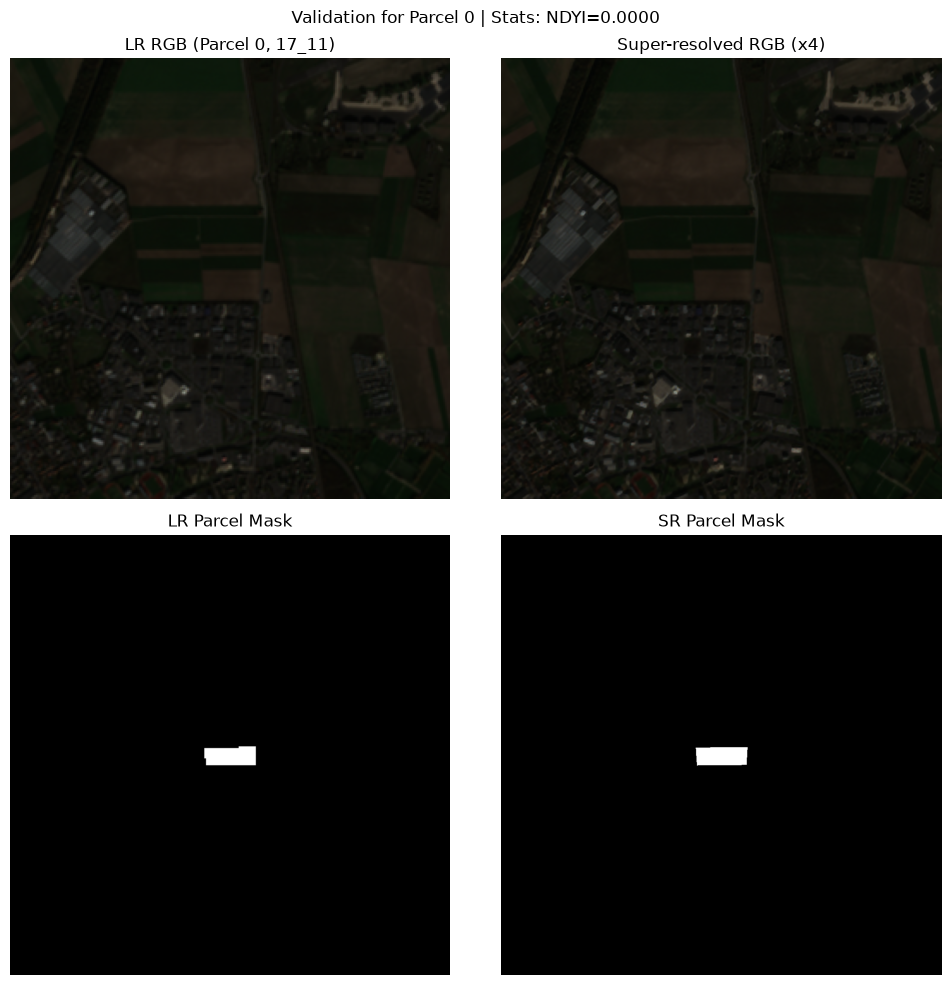


=== Processing Sample 2 (Parcel Index: 7, Obs: 14_09) ===
LR patch read from S3, shape: (10, 256, 256)


100%|██████████| 9/9 [00:21<00:00,  2.40s/it]


SR prediction completed, shape: (10, 1024, 1024)
LR & SR masks generated.
Computed stats: {'NDRE_mean': 0.5022848844528198, 'NDRE_std': 0.05762122943997383, 'NDYVI_mean': 0.3368452787399292, 'NDYVI_std': 0.08776826411485672, 'GCC_mean': 0.4448147714138031, 'GCC_std': 0.024534786120057106, 'NDYI_mean': 0.32157742977142334, 'NDYI_std': 0.02259349636733532, 'mNDblue_mean': -0.6699388027191162, 'mNDblue_std': 0.023505816236138344}


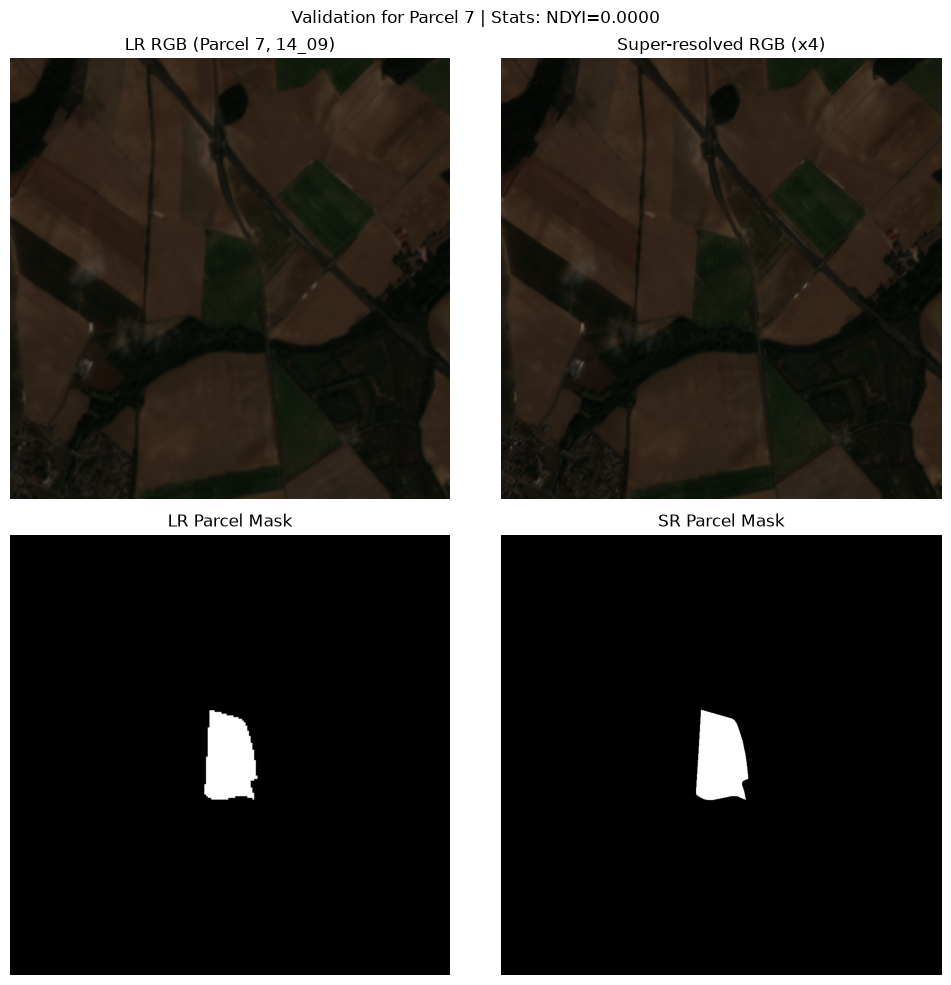


=== Processing Sample 3 (Parcel Index: 8, Obs: 16_06) ===
LR patch read from S3, shape: (10, 256, 256)


100%|██████████| 9/9 [00:24<00:00,  2.68s/it]


SR prediction completed, shape: (10, 1024, 1024)
LR & SR masks generated.
Computed stats: {'NDRE_mean': 0.4233803153038025, 'NDRE_std': 0.03764263913035393, 'NDYVI_mean': 0.2050076723098755, 'NDYVI_std': 0.05753672122955322, 'GCC_mean': 0.40303918719291687, 'GCC_std': 0.013345706276595592, 'NDYI_mean': 0.2737584114074707, 'NDYI_std': 0.019058529287576675, 'mNDblue_mean': -0.6156675815582275, 'mNDblue_std': 0.026017604395747185}


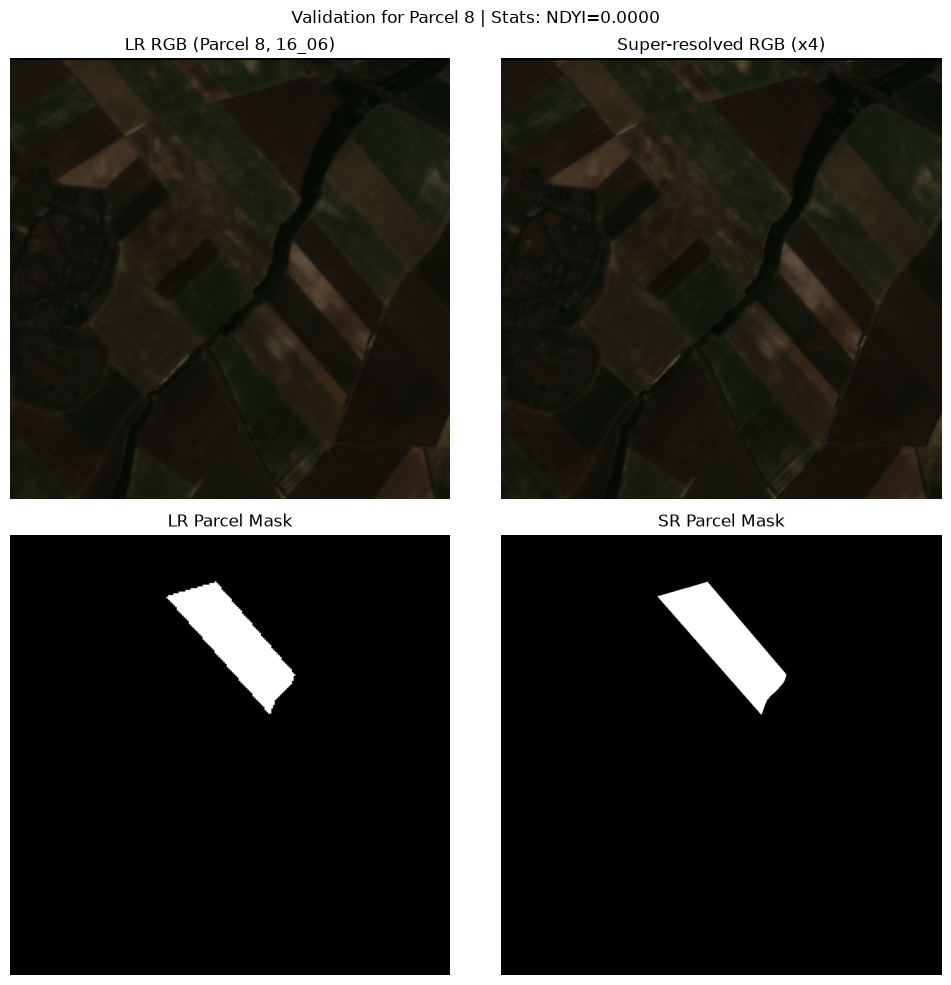


=== Processing Sample 4 (Parcel Index: 14, Obs: 18_06) ===
LR patch read from S3, shape: (10, 256, 256)


100%|██████████| 9/9 [00:22<00:00,  2.49s/it]


SR prediction completed, shape: (10, 1024, 1024)
LR & SR masks generated.
Computed stats: {'NDRE_mean': 0.5151891112327576, 'NDRE_std': 0.02538846805691719, 'NDYVI_mean': 0.35372549295425415, 'NDYVI_std': 0.04113071784377098, 'GCC_mean': 0.45122790336608887, 'GCC_std': 0.014322008937597275, 'NDYI_mean': 0.3325515389442444, 'NDYI_std': 0.01895902305841446, 'mNDblue_mean': -0.6800211668014526, 'mNDblue_std': 0.019559811800718307}


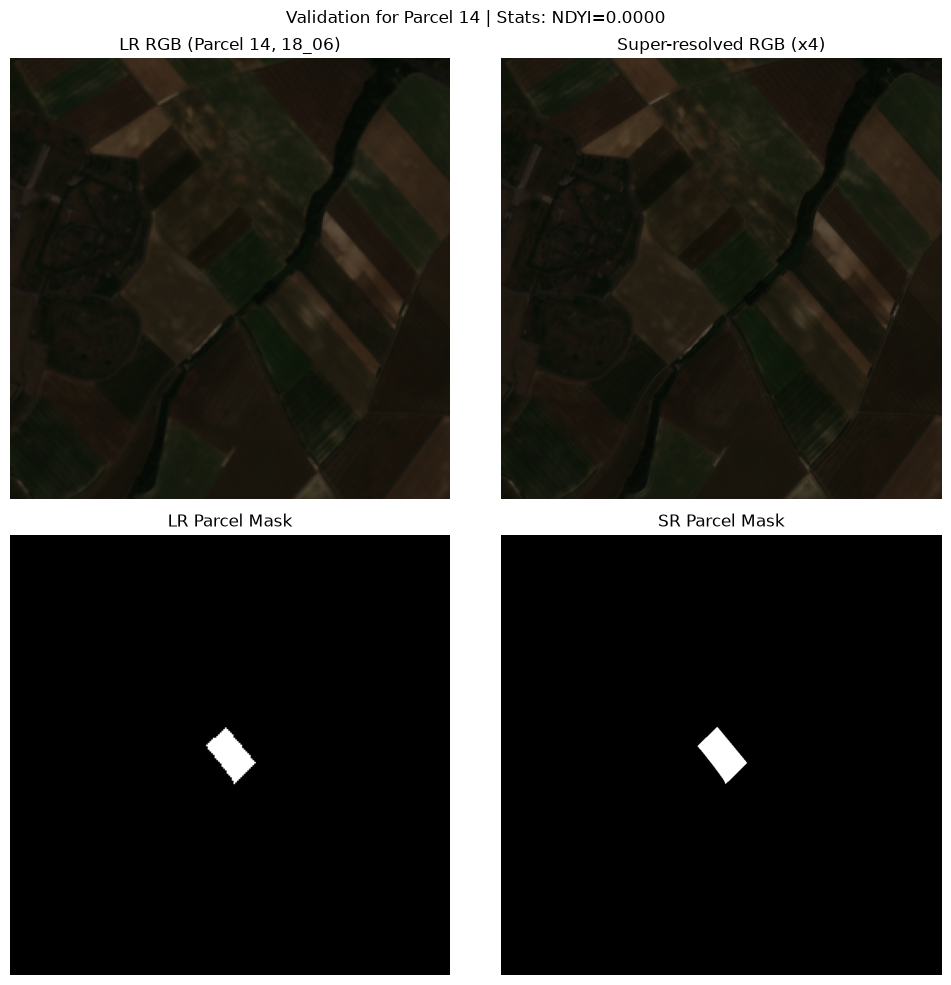

In [14]:
# --- Process 4 patches step-by-step from remote S3 ---

indexer = SpectralIndexComputer()
patch_extractor = ParcelPatchExtractor(min_patch_size=256)

processed_count = 0

for parcel_idx, parcel_row in parcels.iterrows():
    if processed_count >= 4:
        break
        
    # 1. Compute patch window
    window = patch_extractor.compute_window(
        geom=parcel_row.geometry,
        img_height=img_height,
        img_width=img_width,
        raster_transform=raster_transform,
        parcel_index=parcel_idx,
    )
    if window is None:
        continue

    zone_bounds = window.zone.bounds

    # Try to find a valid observation
    valid_obs_col = None
    for obs_col in observation_columns:
        value = parcel_row.get(obs_col)
        if not pd.isna(value) and float(value) > 0:
            valid_obs_col = obs_col
            break
            
    if not valid_obs_col:
        continue
        
    print(f"\n=== Processing Sample {processed_count + 1} (Parcel Index: {parcel_idx}, Obs: {valid_obs_col}) ===")
    
    obs_date = TemporalDateMatcher.parse_observation_column(valid_obs_col)
    s2_date = matcher.find_nearest_s2_date(obs_date)
    band_offset = matcher.get_band_offset(s2_date)

    band_start = band_offset * 10 + 1
    band_indexes = list(range(band_start, band_start + 10))

    # 2. Read LR Patch
    with rasterio.open(stack_path) as src_stack:
        lr_patch = src_stack.read(
            band_indexes,
            window=rasterio.windows.Window(
                col_off=window.col_min,
                row_off=window.row_min,
                width=window.col_max - window.col_min,
                height=window.row_max - window.row_min,
            ),
        )
    
    lr_patch = np.clip(lr_patch.astype(np.float32) / 10000.0, 0, 1)
    print(f"LR patch read from S3, shape: {lr_patch.shape}")

    # 3. Super-resolution
    X = torch.from_numpy(np.nan_to_num(lr_patch)).to(device)
    with torch.no_grad():
        sr_patch = sen2sr.predict_large(
            model=SEN2SRLite,
            X=X,
            overlap=32,
        )
    
    if isinstance(sr_patch, torch.Tensor):
        sr_patch = sr_patch.cpu().numpy()
        
    sr_patch = np.clip(sr_patch.astype(np.float32), 0, 1)
    print(f"SR prediction completed, shape: {sr_patch.shape}")

    # 4. Generate Masks
    lr_mask, sr_mask, lr_transform, sr_transform = ParcelMaskGenerator.create_masks(
        parcel_geometry=parcel_row.geometry,
        zone_bounds=zone_bounds,
        lr_shape=lr_patch.shape[1:],
        sr_shape=sr_patch.shape[1:],
    )
    print("LR & SR masks generated.")

    # 5. Compute Spectral Indices
    stats = indexer.compute_stats(lr_patch, lr_mask)
    print(f"Computed stats: {stats}")

    # 6. Save GeoTIFFs
    # stem = f"val_parcel_{parcel_idx:05d}_{valid_obs_col}"
    # write_geotiff(out_dir / f"{stem}_lr.tif", lr_patch, lr_patch.shape[1], lr_patch.shape[2], lr_patch.shape[0], lr_transform)
    # write_geotiff(out_dir / f"{stem}_sr.tif", sr_patch, sr_patch.shape[1], sr_patch.shape[2], sr_patch.shape[0], sr_transform)
    # write_geotiff(out_dir / f"{stem}_lr_mask.tif", lr_mask.astype(np.uint8), lr_mask.shape[0], lr_mask.shape[1], 1, lr_transform)
    # write_geotiff(out_dir / f"{stem}_sr_mask.tif", sr_mask.astype(np.uint8), sr_mask.shape[0], sr_mask.shape[1], 1, sr_transform)
    # print("GeoTIFFs saved to notebooks/verification_outputs/")

    # 7. Visualize
    visualize_results(lr_patch, sr_patch, lr_mask, sr_mask, stats, parcel_idx, valid_obs_col)
    
    processed_count += 1

In [69]:
print("LR transform")
print(lr_transform)

print("SR transform")
print(sr_transform)

LR transform
| 10.04, 0.00, 739949.98|
| 0.00,-10.04, 6950219.90|
| 0.00, 0.00, 1.00|
SR transform
| 2.51, 0.00, 739949.98|
| 0.00,-2.51, 6950219.90|
| 0.00, 0.00, 1.00|


### Reading Results :

In [4]:
dataset_csv_path = r"../yellowness_dataset/observations_inventory.csv"

dataset = pd.read_csv(dataset_csv_path)
dataset.head(20)

,year,stack_name,parcel_index,id_plot,observation_column,observation_date,s2_date,yellowness,lr_patch,sr_patch,...,sr_NDRE_mean,sr_NDRE_std,sr_NDYVI_mean,sr_NDYVI_std,sr_GCC_mean,sr_GCC_std,sr_NDYI_mean,sr_NDYI_std,sr_mNDblue_mean,sr_mNDblue_std
0,2020,Sentinel2_T31UEQ_TSG,0,10597132,17_11,2020-11-17,2020-11-16,10.0,parcel_00000_17_11_Sentinel2_T31UEQ_TSG_lr.tif,parcel_00000_17_11_Sentinel2_T31UEQ_TSG_sr.tif,...,0.146093,0.022161,-0.168062,0.025638,0.333899,0.004340,0.166754,0.013201,-0.389905,0.028925
1,2020,Sentinel2_T31UEQ_TSG,1,11449063,08_07,2020-07-08,2020-07-09,1.0,parcel_00001_08_07_Sentinel2_T31UEQ_TSG_lr.tif,parcel_00001_08_07_Sentinel2_T31UEQ_TSG_sr.tif,...,0.594365,0.040067,0.476627,0.059720,0.497416,0.022888,0.393023,0.023042,-0.722233,0.018321
2,2020,Sentinel2_T31UEQ_TSG,1,11449063,28_08,2020-08-28,2020-08-28,80.0,parcel_00001_28_08_Sentinel2_T31UEQ_TSG_lr.tif,parcel_00001_28_08_Sentinel2_T31UEQ_TSG_sr.tif,...,0.473810,0.043425,0.298885,0.063126,0.436708,0.014146,0.293586,0.015653,-0.643367,0.021881
3,2020,Sentinel2_T31UEQ_TSG,2,116846,31_08,2020-08-31,2020-09-02,5.0,parcel_00002_31_08_Sentinel2_T31UEQ_TSG_lr.tif,parcel_00002_31_08_Sentinel2_T31UEQ_TSG_sr.tif,...,0.463732,0.067945,0.285786,0.099660,0.442367,0.031569,0.320835,0.036261,-0.657279,0.032800
4,2020,Sentinel2_T31UEQ_TSG,3,13889502,26_06,2020-06-26,2020-06-24,1.0,parcel_00003_26_06_Sentinel2_T31UEQ_TSG_lr.tif,parcel_00003_26_06_Sentinel2_T31UEQ_TSG_sr.tif,...,0.607858,0.045155,0.467709,0.066287,0.451843,0.017769,0.297878,0.019838,-0.655176,0.026134
5,2020,Sentinel2_T31UEQ_TSG,3,13889502,06_07,2020-07-06,2020-07-04,2.0,parcel_00003_06_07_Sentinel2_T31UEQ_TSG_lr.tif,parcel_00003_06_07_Sentinel2_T31UEQ_TSG_sr.tif,...,0.607386,0.041618,0.480908,0.063250,0.477825,0.022056,0.346499,0.025921,-0.676527,0.026275
6,2020,Sentinel2_T31UEQ_TSG,3,13889502,28_09,2020-09-28,2020-09-27,60.0,parcel_00003_28_09_Sentinel2_T31UEQ_TSG_lr.tif,parcel_00003_28_09_Sentinel2_T31UEQ_TSG_sr.tif,...,0.480130,0.040235,0.307030,0.052914,0.437405,0.014043,0.298796,0.018194,-0.629889,0.018461
7,2020,Sentinel2_T31UEQ_TSG,4,13890460,11_09,2020-09-11,2020-09-12,10.0,parcel_00004_11_09_Sentinel2_T31UEQ_TSG_lr.tif,parcel_00004_11_09_Sentinel2_T31UEQ_TSG_sr.tif,...,0.557026,0.039029,0.435009,0.059647,0.498098,0.026921,0.364354,0.027659,-0.691775,0.017974
8,2020,Sentinel2_T31UEQ_TSG,5,13892457,10_09,2020-09-10,2020-09-12,100.0,parcel_00005_10_09_Sentinel2_T31UEQ_TSG_lr.tif,parcel_00005_10_09_Sentinel2_T31UEQ_TSG_sr.tif,...,0.381949,0.040748,0.201731,0.060802,0.454257,0.021598,0.380354,0.027627,-0.673470,0.024829
9,2020,Sentinel2_T31UEQ_TSG,6,13894409,24_06,2020-06-24,2020-06-24,1.0,parcel_00006_24_06_Sentinel2_T31UEQ_TSG_lr.tif,parcel_00006_24_06_Sentinel2_T31UEQ_TSG_sr.tif,...,0.415533,0.041765,0.200116,0.058042,0.412332,0.013994,0.302494,0.018061,-0.634956,0.027099


Parcel: 87179


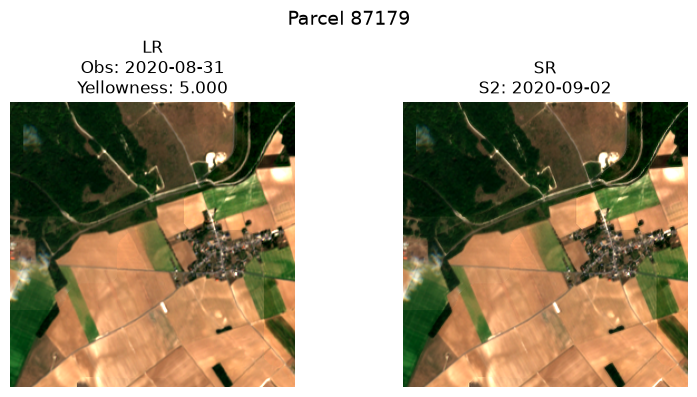

Parcel: 87880


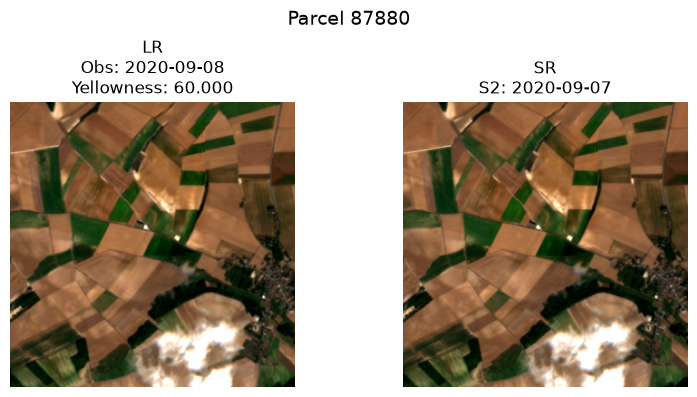

Parcel: 88538


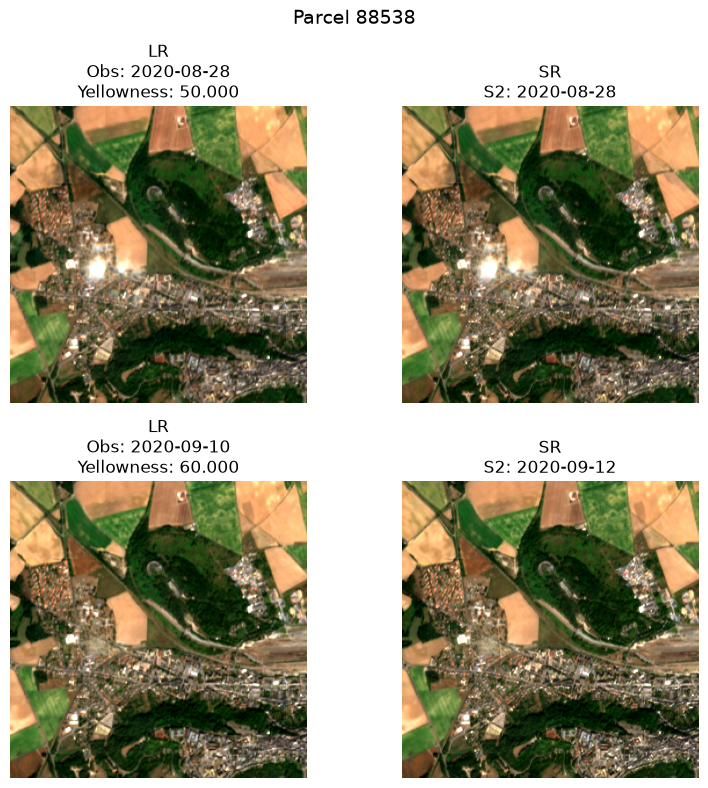

Parcel: 88905


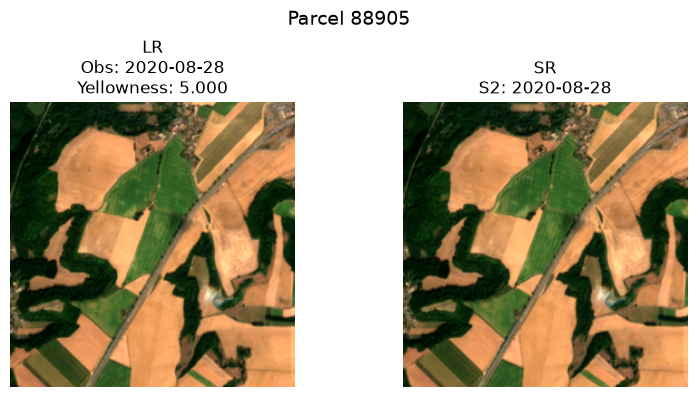

Parcel: 88913


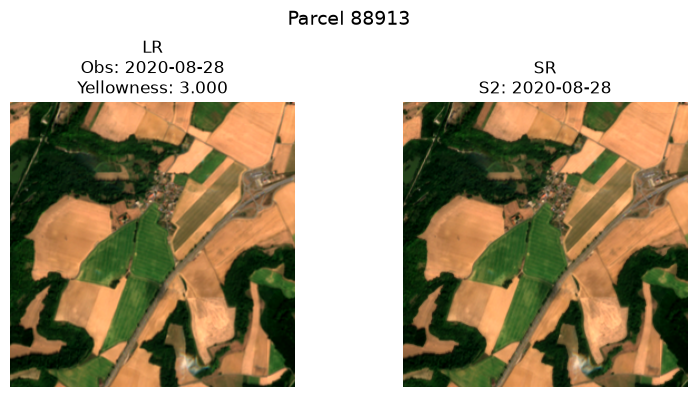

Parcel: 93084


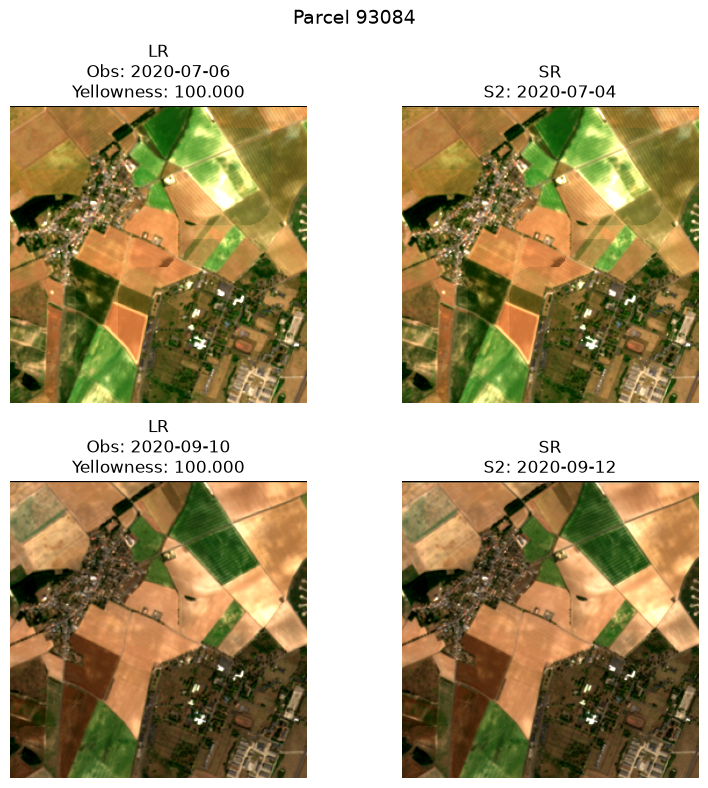

Parcel: 93352


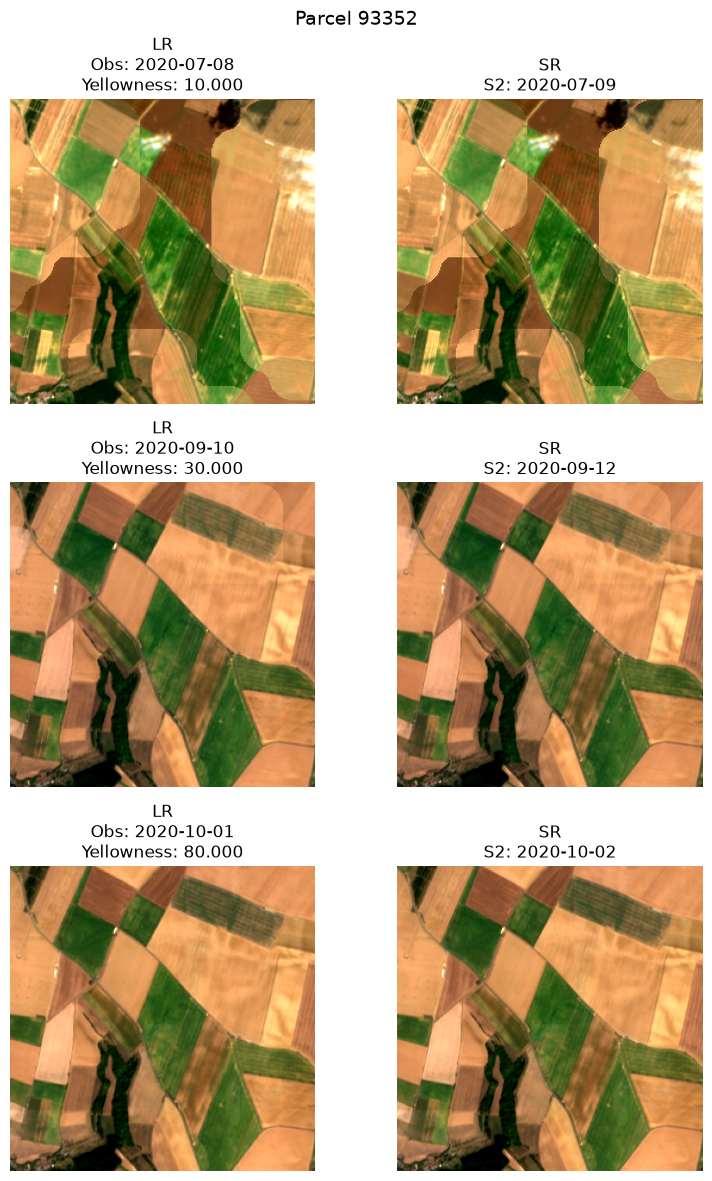

Parcel: 116846


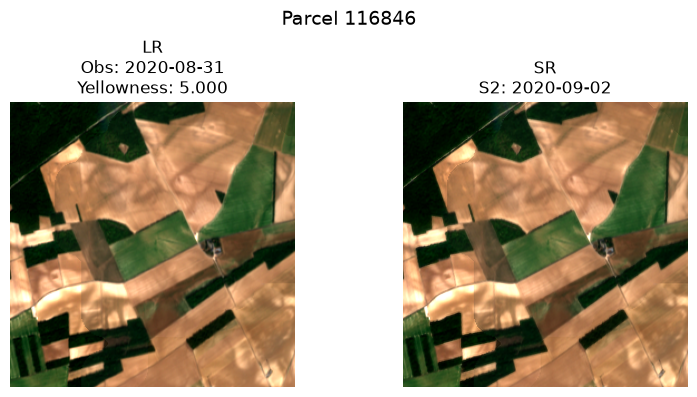

Parcel: 139358


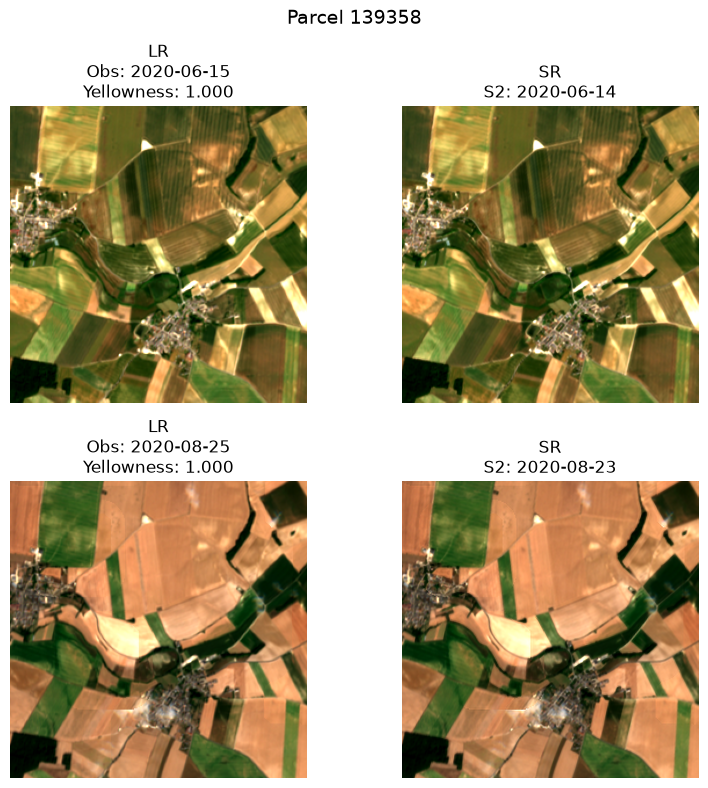

Parcel: 144340


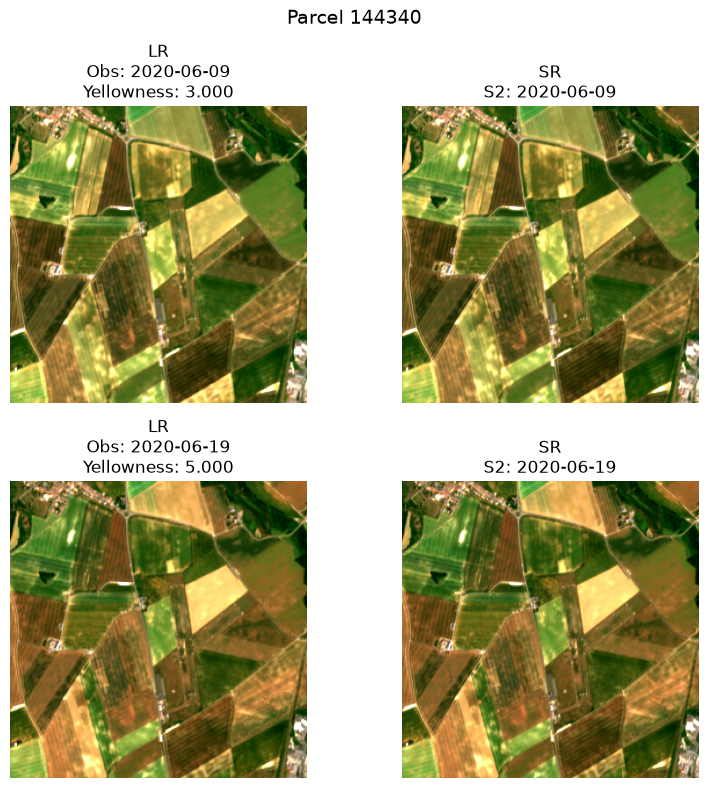

In [9]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import rasterio

dataset_root = Path("../yellowness_dataset")

def read_display_rgb(path: Path) -> np.ndarray:
    """Read B02,B03,B04 and convert to natural RGB for plotting."""
    with rasterio.open(path) as src:
        arr = src.read([1, 2, 3]).astype(np.float32) # B02, B03, B04
        arr = np.moveaxis(arr, 0, -1) # (H, W, C)
        # Handle reflectance [0,1] and DN-like values [0,10000]
    if arr.max() > 1.5:
        arr = arr / 10000.0
    arr = np.clip(arr, 0.0, 1.0)

    # Convert B02,B03,B04 -> R,G,B
    rgb = arr[..., [2, 1, 0]]

    # Optional contrast stretch for readability
    p2, p98 = np.percentile(rgb, (2, 98))
    if p98 > p2:
        rgb = np.clip((rgb - p2) / (p98 - p2), 0.0, 1.0)

    return rgb
i = 0
for plot_id, group in dataset.groupby("id_plot"):
    if i == 10: break
    print(f"Parcel: {plot_id}")
    n = len(group)
    fig, axes = plt.subplots(n, 2, figsize=(8, 4 * n))
    i+=1
    if n == 1:
        axes = np.array([axes])

    for ax_row, (_, row) in zip(axes, group.iterrows()):
        lr_img = read_display_rgb(dataset_root / row["lr_patch"])
        sr_img = read_display_rgb(dataset_root / row["sr_patch"])

        ax_row[0].imshow(lr_img)
        ax_row[0].set_title(
            f"LR\nObs: {row['observation_date']}\nYellowness: {row['yellowness']:.3f}"
        )
        ax_row[0].axis("off")

        ax_row[1].imshow(sr_img)
        ax_row[1].set_title(f"SR\nS2: {row['s2_date']}")
        ax_row[1].axis("off")

    plt.suptitle(f"Parcel {plot_id}", fontsize=14)
    plt.tight_layout()
    plt.show()